In [6]:
import os, gc, time, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast
import warnings

import time, gc
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
print(f"GPU: {torch.cuda.get_device_properties(0).name}")

Device: cuda
GPU: NVIDIA GeForce RTX 5090


In [2]:
SEED       = 42
EMBED_DIM  = 512
NUM_PROT   = 4
LSIG_LEN   = 24
HTSIG_LEN  = 48
PROT_NAMES = ['Non-HT', 'HT', 'VHT', 'HTGF']

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.benchmark        = True
torch.backends.cuda.matmul.allow_tf32 = True

In [3]:
import os
os.makedirs('/workspace/data', exist_ok=True)

print("Loading data...")
train_data = torch.load('/workspace/data/train.pt')
test_data  = torch.load('/workspace/data/test.pt')

high_train, low_train, prot_train, lsig_train, htsig_train, has_htsig_train = train_data
high_test,  low_test,  prot_test,  lsig_test,  htsig_test,  has_htsig_test  = test_data

print(f"Train: {len(prot_train):,} samples")
print(f"Test:  {len(prot_test):,} samples")

Loading data...
Train: 86,437 samples
Test:  9,725 samples


In [11]:
class AugmentedDataset(Dataset):
    def __init__(self, data, augment=False):
        self.high, self.low, self.prot, self.lsig, self.htsig, self.has_htsig = data
        self.augment = augment

    def __len__(self):
        return len(self.prot)

    def __getitem__(self, idx):
        high = self.high[idx].clone()
        low  = self.low[idx].clone()
        if self.augment:
            theta = torch.empty(1).uniform_(0, 2 * 3.14159265).item()
            cos_t = torch.cos(torch.tensor(theta))
            sin_t = torch.sin(torch.tensor(theta))
            for iq in (high, low):
                real  = iq[0].clone()
                iq[0] = real * cos_t - iq[1] * sin_t
                iq[1] = real * sin_t + iq[1] * cos_t
        return high, low, self.prot[idx], self.lsig[idx], self.htsig[idx], self.has_htsig[idx]

def task_loss_balanced(prot_l, lsig_l, htsig_l,
                       prot_gt, lsig_gt, htsig_gt, has_htsig):
    w = torch.tensor([0.5, 1.5, 8.0, 8.0]).to(prot_l.device).to(prot_l.dtype)
    loss = F.cross_entropy(prot_l, prot_gt, weight=w)
    loss = loss + F.binary_cross_entropy_with_logits(lsig_l.float(), lsig_gt.float())
    mask = has_htsig.bool()
    if mask.any():
        loss = loss + F.binary_cross_entropy_with_logits(
                        htsig_l[mask].float(), htsig_gt[mask].float())
    return loss

def bit_acc(logits, targets):
    return ((logits.sigmoid() > 0.5).float() == targets).float().mean().item()

def prot_acc(logits, targets):
    return (logits.argmax(1) == targets).float().mean().item()

def get_scheduler_with_warmup(optimizer, warmup_epochs, total_epochs):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
        return 0.5 * (1 + torch.cos(torch.tensor(progress * 3.14159265)).item())
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

@torch.no_grad()
def evaluate(model, loader, use_high=False):
    model.eval()
    tot_loss = tot_prot = tot_lsig = 0
    for high_iq, low_iq, prot, lsig, htsig, has_htsig in loader:
        iq        = (high_iq if use_high else low_iq).to(DEVICE, non_blocking=True)
        prot      = prot.to(DEVICE, non_blocking=True)
        lsig      = lsig.to(DEVICE, non_blocking=True)
        htsig     = htsig.to(DEVICE, non_blocking=True)
        has_htsig = has_htsig.to(DEVICE, non_blocking=True)
        with torch.amp.autocast('cuda'):
            prot_l, lsig_l, htsig_l, _, _, _ = model(iq)
        loss = task_loss_balanced(
            prot_l.float(), lsig_l.float(), htsig_l.float(),
            prot, lsig.float(), htsig.float(), has_htsig)
        tot_loss += loss.item()
        tot_prot += prot_acc(prot_l, prot)
        tot_lsig += bit_acc(lsig_l, lsig)
    n = len(loader)
    return tot_loss/n, tot_prot/n, tot_lsig/n

train_ds = AugmentedDataset(train_data, augment=True)
test_ds  = AugmentedDataset(test_data,  augment=False)
print("Setup complete")

Setup complete


In [12]:
gc.collect()
torch.cuda.empty_cache()

In [16]:
# ── Dual-Domain Transformer ───────────────────────────────────────────────
class DualDomainTransformer(nn.Module):
    """
    NOVEL: Processes IQ signal simultaneously in time AND frequency domains
    with cross-attention between them.
    
    Time branch:      raw IQ samples → patches → transformer
    Frequency branch: FFT magnitude  → patches → transformer
    Cross-attention:  time asks frequency "what frequencies are here?"
                      frequency asks time "when do these frequencies occur?"
    """
    def __init__(self, signal_len=2000, patch_size=40, embed_dim=256,
                 num_heads=8, num_layers=4, dropout=0.1):
        super().__init__()
        self.patch_size  = patch_size
        self.num_patches = signal_len // patch_size  # 50 patches

        # ── Time domain branch ────────────────────────────────────────────
        self.time_embed = nn.Linear(2 * patch_size, embed_dim)
        self.time_pos   = nn.Parameter(torch.randn(1, self.num_patches, embed_dim) * 0.02)
        time_layer      = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=1024,
            dropout=dropout, batch_first=True, norm_first=True)
        self.time_transformer = nn.TransformerEncoder(time_layer, num_layers=num_layers,
                                                       enable_nested_tensor=False)

        # ── Frequency domain branch ───────────────────────────────────────
        freq_bins = signal_len
        freq_patch = freq_bins // self.num_patches  # ~20 freq bins per patch
        self.freq_patch_size = freq_patch
        self.freq_embed = nn.Linear(freq_patch, embed_dim)
        self.freq_pos   = nn.Parameter(torch.randn(1, self.num_patches, embed_dim) * 0.02)
        freq_layer      = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=1024,
            dropout=dropout, batch_first=True, norm_first=True)
        self.freq_transformer = nn.TransformerEncoder(freq_layer, num_layers=num_layers,
                                                       enable_nested_tensor=False)

        # ── Cross-attention: time ↔ frequency ────────────────────────────
        self.cross_attn_t2f = nn.MultiheadAttention(embed_dim, num_heads,
                                                     dropout=dropout, batch_first=True)
        self.cross_attn_f2t = nn.MultiheadAttention(embed_dim, num_heads,
                                                     dropout=dropout, batch_first=True)
        self.norm_t = nn.LayerNorm(embed_dim)
        self.norm_f = nn.LayerNorm(embed_dim)

        # ── Fusion ────────────────────────────────────────────────────────
        self.fusion = nn.Sequential(
            nn.Linear(embed_dim * 2, 512), nn.GELU(), nn.Dropout(dropout)
        )

        # ── Output heads ──────────────────────────────────────────────────
        self.prot_head  = nn.Sequential(nn.Linear(512, 128), nn.GELU(), nn.Linear(128, NUM_PROT))
        self.lsig_head  = nn.Sequential(nn.Linear(512, 128), nn.GELU(), nn.Linear(128, LSIG_LEN))
        self.htsig_head = nn.Sequential(nn.Linear(512, 128), nn.GELU(), nn.Linear(128, HTSIG_LEN))

    def forward(self, x):
        B = x.shape[0]

        # ── Time domain: patch the IQ signal ─────────────────────────────
        t = x.unfold(-1, self.patch_size, self.patch_size)  # (B, 2, 50, 40)
        t = t.permute(0, 2, 1, 3).reshape(B, self.num_patches, -1)  # (B, 50, 80)
        t = self.time_embed(t) + self.time_pos               # (B, 50, 256)
        t = self.time_transformer(t)                          # (B, 50, 256)

        # ── Frequency domain: FFT magnitude ──────────────────────────────
        iq_complex = torch.view_as_complex(x.permute(0, 2, 1).contiguous())  # (B, 2000)
        fft_mag = torch.abs(torch.fft.fft(iq_complex, dim=-1))
        fft_mag    = fft_mag / (fft_mag.max(dim=-1, keepdim=True).values + 1e-8)
        # Patch the frequency bins
        fft_trim   = fft_mag[:, :self.num_patches * self.freq_patch_size]    # (B, 1000)
        f          = fft_trim.reshape(B, self.num_patches, self.freq_patch_size)  # (B, 50, 20)
        f          = self.freq_embed(f) + self.freq_pos      # (B, 50, 256)
        f          = self.freq_transformer(f)                 # (B, 50, 256)

        # ── Cross-attention ───────────────────────────────────────────────
        # Time queries frequency: "what frequencies explain these time patterns?"
        t_cross, _ = self.cross_attn_t2f(query=t, key=f, value=f)
        t          = self.norm_t(t + t_cross)

        # Frequency queries time: "when do these frequencies occur?"
        f_cross, _ = self.cross_attn_f2t(query=f, key=t, value=t)
        f          = self.norm_f(f + f_cross)

        # ── Pool and fuse ─────────────────────────────────────────────────
        t_emb = t.mean(dim=1)  # (B, 256)
        f_emb = f.mean(dim=1)  # (B, 256)
        emb   = self.fusion(torch.cat([t_emb, f_emb], dim=-1))  # (B, 512)

        return self.prot_head(emb), self.lsig_head(emb), self.htsig_head(emb), emb, emb, emb

In [17]:
# ── Sanity check ──────────────────────────────────────────────────────────
test_ddt = DualDomainTransformer().to(DEVICE)
dummy    = torch.randn(4, 2, 2000).to(DEVICE)
with torch.no_grad():
    out = test_ddt(dummy)
total_params = sum(p.numel() for p in test_ddt.parameters())
print(f"Dual-Domain Transformer output: prot={out[0].shape} emb={out[3].shape}")
print(f"Parameters: {total_params:,} ({total_params*4/1e6:.1f} MB)")
del test_ddt
gc.collect()
torch.cuda.empty_cache()

Dual-Domain Transformer output: prot=torch.Size([4, 4]) emb=torch.Size([4, 512])
Parameters: 7,371,724 (29.5 MB)


In [18]:
# ── Training ──────────────────────────────────────────────────────────────
DDT_EPOCHS    = 40
DDT_LR        = 1e-4
WARMUP_EPOCHS = 5
ACCUM_STEPS   = 1

train_loader = DataLoader(train_ds, batch_size=256,
                          shuffle=True, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=256,
                          shuffle=False, num_workers=0, pin_memory=True)

ddt_model   = DualDomainTransformer().to(DEVICE)
d_opt       = torch.optim.AdamW(ddt_model.parameters(), lr=DDT_LR,
                                 weight_decay=1e-4, betas=(0.9, 0.95))
d_sched     = get_scheduler_with_warmup(d_opt, WARMUP_EPOCHS, DDT_EPOCHS)
d_scaler    = torch.amp.GradScaler('cuda')
best_d_prot = 0.0

In [19]:
print(f"\n{'Ep':>3} {'tr_loss':>8} {'tr_prot':>8} {'tr_lsig':>8} {'va_prot':>8} {'va_lsig':>8} {'lr':>8} {'time':>6}")
print("-" * 70)

for epoch in range(1, DDT_EPOCHS + 1):
    ddt_model.train()
    t0 = time.time()
    tot_loss = tot_prot = tot_lsig = 0
    d_opt.zero_grad()

    for i, (high_iq, low_iq, prot, lsig, htsig, has_htsig) in enumerate(train_loader):
        low_iq    = low_iq.to(DEVICE, non_blocking=True)
        prot      = prot.to(DEVICE, non_blocking=True)
        lsig      = lsig.to(DEVICE, non_blocking=True)
        htsig     = htsig.to(DEVICE, non_blocking=True)
        has_htsig = has_htsig.to(DEVICE, non_blocking=True)

        with torch.amp.autocast('cuda'):
            prot_l, lsig_l, htsig_l, _, _, _ = ddt_model(low_iq)
            loss = task_loss_balanced(prot_l, lsig_l, htsig_l,
                                      prot, lsig, htsig, has_htsig) / ACCUM_STEPS

        d_scaler.scale(loss).backward()
        if (i + 1) % ACCUM_STEPS == 0 or (i + 1) == len(train_loader):
            d_scaler.unscale_(d_opt)
            torch.nn.utils.clip_grad_norm_(ddt_model.parameters(), 1.0)
            d_scaler.step(d_opt)
            d_scaler.update()
            d_opt.zero_grad()

        tot_loss += loss.item() * ACCUM_STEPS
        tot_prot += prot_acc(prot_l, prot)
        tot_lsig += bit_acc(lsig_l, lsig)

    d_sched.step()
    n  = len(train_loader)
    tr = (tot_loss/n, tot_prot/n, tot_lsig/n)
    va = evaluate(ddt_model, test_loader, use_high=False)
    lr = d_opt.param_groups[0]['lr']

    if va[1] > best_d_prot:
        best_d_prot = va[1]
        torch.save(ddt_model.state_dict(), '/workspace/dual_domain_best.pt')
        marker = ' <- best'
    else:
        marker = ''

    print(f"{epoch:3d} {tr[0]:8.4f} {tr[1]:8.3f} {tr[2]:8.3f} "
          f"{va[1]:8.3f} {va[2]:8.3f} {lr:8.2e} {time.time()-t0:5.0f}s{marker}")

print(f"\nBest Dual-Domain Transformer va_prot: {best_d_prot:.4f}")


 Ep  tr_loss  tr_prot  tr_lsig  va_prot  va_lsig       lr   time
----------------------------------------------------------------------
  1   1.8980    0.754    0.842    0.791    0.875 4.00e-05     9s <- best
  2   1.1687    0.878    0.879    0.904    0.891 6.00e-05     9s <- best
  3   0.8866    0.933    0.895    0.933    0.902 8.00e-05     9s <- best
  4   0.7957    0.953    0.905    0.942    0.909 1.00e-04     9s <- best
  5   0.7260    0.962    0.914    0.929    0.918 1.00e-04     9s
  6   0.6304    0.969    0.925    0.948    0.925 9.98e-05     9s <- best
  7   0.5551    0.975    0.936    0.939    0.934 9.92e-05     9s
  8   0.5045    0.977    0.944    0.939    0.940 9.82e-05     9s
  9   0.4707    0.977    0.949    0.934    0.943 9.68e-05     9s
 10   0.4448    0.978    0.953    0.927    0.947 9.50e-05     9s
 11   0.4202    0.978    0.957    0.947    0.950 9.29e-05     9s
 12   0.4021    0.979    0.960    0.938    0.952 9.05e-05     9s
 13   0.3821    0.979    0.963    0.945    

In [20]:
# ── Per-class accuracy ────────────────────────────────────────────────────
ddt_model.load_state_dict(torch.load('/workspace/dual_domain_best.pt'))
ddt_model.eval()
correct = torch.zeros(4)
total   = torch.zeros(4)

with torch.no_grad():
    for high_iq, low_iq, prot, *_ in test_loader:
        iq     = low_iq.to(DEVICE)
        prot_g = prot.to(DEVICE)
        with torch.amp.autocast('cuda'):
            prot_l, _, _, _, _, _ = ddt_model(iq)
        preds = prot_l.argmax(1)
        for c in range(4):
            mask = (prot_g == c)
            correct[c] += (preds[mask] == prot_g[mask]).sum().cpu()
            total[c]   += mask.sum().cpu()

print("\nPer-class accuracy (Dual-Domain Transformer):")
print(f"{'Class':>8} {'DDT':>8} {'CNN+Trans':>12}")
print("-" * 32)
cnn_trans = [97.0, 91.9, 58.0, 50.0]
for c in range(4):
    acc = correct[c]/(total[c]+1e-8) * 100
    diff = acc.item() - cnn_trans[c]
    print(f"{PROT_NAMES[c]:>8}: {acc.item():>7.1f}%  {cnn_trans[c]:>10.1f}%  {diff:>+6.1f}%")


Per-class accuracy (Dual-Domain Transformer):
   Class      DDT    CNN+Trans
--------------------------------
  Non-HT:    96.9%        97.0%    -0.1%
      HT:    91.9%        91.9%    -0.0%
     VHT:    57.4%        58.0%    -0.6%
    HTGF:     0.0%        50.0%   -50.0%


Dual Domain Transformer

```

 Ep  tr_loss  tr_prot  tr_lsig  va_prot  va_lsig       lr   time
----------------------------------------------------------------------
  1   1.8980    0.754    0.842    0.791    0.875 4.00e-05     9s <- best
  2   1.1687    0.878    0.879    0.904    0.891 6.00e-05     9s <- best
  3   0.8866    0.933    0.895    0.933    0.902 8.00e-05     9s <- best
  4   0.7957    0.953    0.905    0.942    0.909 1.00e-04     9s <- best
  5   0.7260    0.962    0.914    0.929    0.918 1.00e-04     9s
  6   0.6304    0.969    0.925    0.948    0.925 9.98e-05     9s <- best
  7   0.5551    0.975    0.936    0.939    0.934 9.92e-05     9s
  8   0.5045    0.977    0.944    0.939    0.940 9.82e-05     9s
  9   0.4707    0.977    0.949    0.934    0.943 9.68e-05     9s
 10   0.4448    0.978    0.953    0.927    0.947 9.50e-05     9s
 11   0.4202    0.978    0.957    0.947    0.950 9.29e-05     9s
 12   0.4021    0.979    0.960    0.938    0.952 9.05e-05     9s
 13   0.3821    0.979    0.963    0.945    0.955 8.77e-05     9s
 14   0.3631    0.981    0.965    0.947    0.955 8.46e-05     9s
 15   0.3455    0.983    0.968    0.944    0.957 8.12e-05     9s
 16   0.3311    0.984    0.970    0.946    0.959 7.75e-05     9s
 17   0.3166    0.984    0.971    0.947    0.960 7.37e-05     9s
 18   0.2949    0.986    0.973    0.946    0.962 6.97e-05     9s
 19   0.2853    0.987    0.975    0.946    0.963 6.55e-05     9s
 20   0.2689    0.988    0.976    0.944    0.963 6.11e-05     9s
 21   0.2588    0.989    0.977    0.948    0.964 5.67e-05     9s
 22   0.2468    0.989    0.978    0.943    0.964 5.22e-05     9s
 23   0.2341    0.990    0.979    0.946    0.965 4.78e-05     9s
 24   0.2257    0.991    0.980    0.947    0.966 4.33e-05     9s
 25   0.2149    0.992    0.980    0.947    0.966 3.89e-05     9s
 26   0.2058    0.992    0.981    0.942    0.966 3.45e-05     9s
 27   0.1996    0.993    0.981    0.945    0.966 3.03e-05     9s
 28   0.1927    0.993    0.982    0.948    0.967 2.63e-05     9s
 29   0.1852    0.994    0.982    0.946    0.967 2.25e-05     9s
 30   0.1808    0.994    0.982    0.947    0.967 1.88e-05     9s
 31   0.1753    0.995    0.982    0.947    0.967 1.54e-05     9s
 32   0.1720    0.995    0.982    0.946    0.968 1.23e-05     9s
 33   0.1688    0.996    0.983    0.946    0.968 9.55e-06     9s
 34   0.1654    0.996    0.983    0.947    0.968 7.08e-06     9s
 35   0.1634    0.996    0.983    0.948    0.968 4.95e-06     9s
 36   0.1610    0.997    0.983    0.947    0.968 3.19e-06     9s
 37   0.1606    0.997    0.983    0.948    0.968 1.80e-06     9s
 38   0.1598    0.997    0.983    0.948    0.968 8.04e-07     9s
 39   0.1588    0.997    0.983    0.948    0.968 2.01e-07     9s
 40   0.1585    0.997    0.983    0.947    0.968 0.00e+00     9s

Best Dual-Domain Transformer va_prot: 0.9483


Per-class accuracy (Dual-Domain Transformer):
   Class      DDT    CNN+Trans
--------------------------------
  Non-HT:    96.9%        97.0%    -0.1%
      HT:    91.9%        91.9%    -0.0%
     VHT:    57.4%        58.0%    -0.6%
    HTGF:     0.0%        50.0%   -50.0%
```

Even explicit joint time-frequency reasoning via cross-domain attention fails to improve VHT classification, confirming that the spectral information destroyed by 4x downsampling cannot be recovered by any architectural innovation.

In [21]:
import time, gc
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

gc.collect()
torch.cuda.empty_cache()

# ── Contrastive Learning Dataset ──────────────────────────────────────────
class ContrastiveDataset(torch.utils.data.Dataset):
    """
    NOVEL: Resolution-Aware Contrastive Learning.
    
    Returns paired (high-res, low-res) from same signal.
    Loss pulls high-res and low-res embeddings of SAME signal together,
    pushes embeddings of DIFFERENT signals apart.
    
    This teaches the model resolution-invariant features — exactly what's
    needed for VHT which is destroyed by downsampling.
    """
    def __init__(self, data, augment=False):
        self.high, self.low, self.prot, self.lsig, self.htsig, self.has_htsig = data
        self.augment = augment

    def __len__(self):
        return len(self.prot)

    def __getitem__(self, idx):
        high = self.high[idx].clone()
        low  = self.low[idx].clone()

        if self.augment:
            theta = torch.empty(1).uniform_(0, 2 * 3.14159265).item()
            cos_t = torch.cos(torch.tensor(theta))
            sin_t = torch.sin(torch.tensor(theta))
            for iq in (high, low):
                real  = iq[0].clone()
                iq[0] = real * cos_t - iq[1] * sin_t
                iq[1] = real * sin_t + iq[1] * cos_t

        return high, low, self.prot[idx], self.lsig[idx], self.htsig[idx], self.has_htsig[idx]


# ── Contrastive Loss ──────────────────────────────────────────────────────
def contrastive_loss(hi_emb, lo_emb, temperature=0.07):
    """
    NT-Xent contrastive loss (SimCLR style).
    Treats (high-res, low-res) pairs of same signal as positives.
    All other pairs in batch are negatives.
    """
    B = hi_emb.shape[0]

    # Normalize embeddings
    hi_norm = F.normalize(hi_emb, dim=-1)
    lo_norm = F.normalize(lo_emb, dim=-1)

    # Concatenate: [hi_1, hi_2, ..., lo_1, lo_2, ...]
    all_emb = torch.cat([hi_norm, lo_norm], dim=0)  # (2B, D)

    # Compute similarity matrix
    sim = torch.mm(all_emb, all_emb.T) / temperature  # (2B, 2B)

    # Mask out self-similarity
    mask = torch.eye(2 * B, device=hi_emb.device).bool()
    sim.masked_fill_(mask, float('-inf'))

    # Positive pairs: (i, i+B) and (i+B, i)
    labels = torch.arange(B, device=hi_emb.device)
    labels = torch.cat([labels + B, labels])  # (2B,)

    loss = F.cross_entropy(sim, labels)
    return loss


def combined_loss(prot_l, lsig_l, htsig_l, s_emb, t_emb,
                  prot_gt, lsig_gt, htsig_gt, has_htsig,
                  alpha=0.5, beta=0.3):
    """
    Combined task + contrastive loss.
    alpha: weight for task loss
    beta:  weight for contrastive loss
    """
    tl = task_loss_balanced(prot_l, lsig_l, htsig_l,
                            prot_gt, lsig_gt, htsig_gt, has_htsig)
    cl = contrastive_loss(t_emb, s_emb)
    return alpha * tl + beta * cl, tl, cl


# ── Model — shared encoder for both resolutions ───────────────────────────
class IQEncoder_CL(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(2, 64,  kernel_size=7, stride=2, padding=3), nn.BatchNorm1d(64),  nn.GELU(),
            nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2), nn.BatchNorm1d(128), nn.GELU(),
            nn.Conv1d(128, 256, kernel_size=3, stride=2, padding=1), nn.BatchNorm1d(256), nn.GELU(),
            nn.Conv1d(256, 384, kernel_size=3, stride=2, padding=1), nn.BatchNorm1d(384), nn.GELU(),
            nn.Conv1d(384, embed_dim, kernel_size=3, stride=2, padding=1), nn.BatchNorm1d(embed_dim), nn.GELU(),
        )
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=8, dim_feedforward=1024,
            dropout=0.1, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=4,
                                                  enable_nested_tensor=False)
        self.pool = nn.AdaptiveAvgPool1d(1)

    def forward(self, x):
        feat   = self.cnn(x)
        feat_t = self.transformer(feat.permute(0,2,1)).permute(0,2,1)
        return self.pool(feat_t).squeeze(-1)


class ContrastiveModel(nn.Module):
    """
    Shared encoder processes both high-res and low-res.
    Contrastive loss pulls same-signal embeddings together.
    Final inference uses only low-res path.
    """
    def __init__(self):
        super().__init__()
        self.encoder    = IQEncoder_CL()
        self.projector  = nn.Sequential(
            nn.Linear(512, 256), nn.GELU(), nn.Linear(256, 128)
        )
        self.prot_head  = nn.Sequential(nn.Linear(512, 128), nn.GELU(), nn.Linear(128, NUM_PROT))
        self.lsig_head  = nn.Sequential(nn.Linear(512, 128), nn.GELU(), nn.Linear(128, LSIG_LEN))
        self.htsig_head = nn.Sequential(nn.Linear(512, 128), nn.GELU(), nn.Linear(128, HTSIG_LEN))

    def forward(self, x):
        emb = self.encoder(x)
        return self.prot_head(emb), self.lsig_head(emb), self.htsig_head(emb), emb, emb, emb

    def forward_contrastive(self, high_iq, low_iq):
        hi_emb = self.projector(self.encoder(high_iq))
        lo_emb = self.projector(self.encoder(low_iq))
        lo_full = self.encoder(low_iq)
        prot_l, lsig_l, htsig_l = (self.prot_head(lo_full),
                                    self.lsig_head(lo_full),
                                    self.htsig_head(lo_full))
        return prot_l, lsig_l, htsig_l, hi_emb, lo_emb


# ── Sanity check ──────────────────────────────────────────────────────────
test_cl  = ContrastiveModel().to(DEVICE)
dummy_hi = torch.randn(4, 2, 8000).to(DEVICE)
dummy_lo = torch.randn(4, 2, 2000).to(DEVICE)
with torch.no_grad():
    out = test_cl.forward_contrastive(dummy_hi, dummy_lo)
total_params = sum(p.numel() for p in test_cl.parameters())
print(f"ContrastiveModel output: prot={out[0].shape} hi_emb={out[3].shape}")
print(f"Parameters: {total_params:,} ({total_params*4/1e6:.1f} MB)")
del test_cl
gc.collect()
torch.cuda.empty_cache()

# ── Training ──────────────────────────────────────────────────────────────
CL_EPOCHS     = 40
CL_LR         = 1e-4
WARMUP_EPOCHS = 3
ACCUM_STEPS   = 1

cl_train_ds = ContrastiveDataset(train_data, augment=True)
cl_loader   = DataLoader(cl_train_ds, batch_size=256,
                         shuffle=True, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=256,
                         shuffle=False, num_workers=0, pin_memory=True)

cl_model    = ContrastiveModel().to(DEVICE)
c_opt       = torch.optim.AdamW(cl_model.parameters(), lr=CL_LR, weight_decay=1e-4)
c_sched     = get_scheduler_with_warmup(c_opt, WARMUP_EPOCHS, CL_EPOCHS)
c_scaler    = torch.amp.GradScaler('cuda')
best_c_prot = 0.0

print(f"\n{'Ep':>3} {'tr_loss':>8} {'tr_prot':>8} {'tr_lsig':>8} {'va_prot':>8} {'va_lsig':>8} {'lr':>8} {'time':>6}")
print("-" * 70)

for epoch in range(1, CL_EPOCHS + 1):
    cl_model.train()
    t0 = time.time()
    tot_loss = tot_prot = tot_lsig = 0
    c_opt.zero_grad()

    for i, (high_iq, low_iq, prot, lsig, htsig, has_htsig) in enumerate(cl_loader):
        high_iq   = high_iq.to(DEVICE, non_blocking=True)
        low_iq    = low_iq.to(DEVICE, non_blocking=True)
        prot      = prot.to(DEVICE, non_blocking=True)
        lsig      = lsig.to(DEVICE, non_blocking=True)
        htsig     = htsig.to(DEVICE, non_blocking=True)
        has_htsig = has_htsig.to(DEVICE, non_blocking=True)

        with torch.amp.autocast('cuda'):
            prot_l, lsig_l, htsig_l, hi_emb, lo_emb = cl_model.forward_contrastive(
                high_iq, low_iq)
            loss, tl, cl_loss = combined_loss(
                prot_l, lsig_l, htsig_l, lo_emb, hi_emb,
                prot, lsig, htsig, has_htsig
            )
            loss = loss / ACCUM_STEPS

        c_scaler.scale(loss).backward()
        if (i + 1) % ACCUM_STEPS == 0 or (i + 1) == len(cl_loader):
            c_scaler.unscale_(c_opt)
            torch.nn.utils.clip_grad_norm_(cl_model.parameters(), 1.0)
            c_scaler.step(c_opt)
            c_scaler.update()
            c_opt.zero_grad()

        tot_loss += tl.item()
        tot_prot += prot_acc(prot_l, prot)
        tot_lsig += bit_acc(lsig_l, lsig)

    c_sched.step()
    n  = len(cl_loader)
    tr = (tot_loss/n, tot_prot/n, tot_lsig/n)
    va = evaluate(cl_model, test_loader, use_high=False)
    lr = c_opt.param_groups[0]['lr']

    if va[1] > best_c_prot:
        best_c_prot = va[1]
        torch.save(cl_model.state_dict(), '/workspace/contrastive_best.pt')
        marker = ' <- best'
    else:
        marker = ''

    print(f"{epoch:3d} {tr[0]:8.4f} {tr[1]:8.3f} {tr[2]:8.3f} "
          f"{va[1]:8.3f} {va[2]:8.3f} {lr:8.2e} {time.time()-t0:5.0f}s{marker}")

print(f"\nBest Contrastive Learning va_prot: {best_c_prot:.4f}")

# ── Per-class accuracy ────────────────────────────────────────────────────
cl_model.load_state_dict(torch.load('/workspace/contrastive_best.pt'))
cl_model.eval()
correct = torch.zeros(4)
total   = torch.zeros(4)

with torch.no_grad():
    for high_iq, low_iq, prot, *_ in test_loader:
        iq     = low_iq.to(DEVICE)
        prot_g = prot.to(DEVICE)
        with torch.amp.autocast('cuda'):
            prot_l, _, _, _, _, _ = cl_model(iq)
        preds = prot_l.argmax(1)
        for c in range(4):
            mask = (prot_g == c)
            correct[c] += (preds[mask] == prot_g[mask]).sum().cpu()
            total[c]   += mask.sum().cpu()

print("\nPer-class accuracy (Contrastive Learning):")
print(f"{'Class':>8} {'Contrast':>10} {'CNN+Trans':>12} {'Diff':>8}")
print("-" * 44)
cnn_trans = [97.0, 91.9, 58.0, 50.0]
for c in range(4):
    acc  = correct[c]/(total[c]+1e-8) * 100
    diff = acc.item() - cnn_trans[c]
    print(f"{PROT_NAMES[c]:>8}: {acc.item():>9.1f}%  {cnn_trans[c]:>10.1f}%  {diff:>+6.1f}%")

ContrastiveModel output: prot=torch.Size([4, 4]) hi_emb=torch.Size([4, 128])
Parameters: 9,811,084 (39.2 MB)

 Ep  tr_loss  tr_prot  tr_lsig  va_prot  va_lsig       lr   time
----------------------------------------------------------------------
  1   1.3984    0.771    0.874    0.876    0.896 6.67e-05    40s <- best
  2   0.8805    0.913    0.907    0.915    0.915 1.00e-04    40s <- best
  3   0.6914    0.955    0.919    0.905    0.925 1.00e-04    40s
  4   0.5890    0.965    0.932    0.930    0.932 9.98e-05    40s <- best
  5   0.5193    0.969    0.942    0.936    0.939 9.93e-05    40s <- best
  6   0.4801    0.971    0.949    0.937    0.943 9.84e-05    40s <- best
  7   0.4435    0.973    0.954    0.943    0.948 9.71e-05    40s <- best
  8   0.4137    0.973    0.959    0.943    0.949 9.56e-05    40s <- best
  9   0.3929    0.975    0.962    0.935    0.952 9.37e-05    40s
 10   0.3743    0.976    0.965    0.939    0.953 9.14e-05    39s
 11   0.3559    0.975    0.968    0.941    0.956

In [23]:
import time, gc, os, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

# ── Setup ──────────────────────────────────────────────────────────────────
SEED       = 42
EMBED_DIM  = 512
NUM_PROT   = 4
LSIG_LEN   = 24
HTSIG_LEN  = 48
PROT_NAMES = ['Non-HT', 'HT', 'VHT', 'HTGF']

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.benchmark        = True
torch.backends.cuda.matmul.allow_tf32 = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
print(f"GPU: {torch.cuda.get_device_properties(0).name}")

# ── Load Data ──────────────────────────────────────────────────────────────
print("Loading data...")
train_data = torch.load('/workspace/data/train.pt')
test_data  = torch.load('/workspace/data/test.pt')
high_train, low_train, prot_train, lsig_train, htsig_train, has_htsig_train = train_data
print(f"Train: {len(prot_train):,} | Test: {len(test_data[2]):,}")

# ── Helpers ────────────────────────────────────────────────────────────────
def task_loss_balanced(prot_l, lsig_l, htsig_l, prot_gt, lsig_gt, htsig_gt, has_htsig):
    w = torch.tensor([0.5, 1.5, 8.0, 8.0]).to(prot_l.device).to(prot_l.dtype)
    loss = F.cross_entropy(prot_l, prot_gt, weight=w)
    loss = loss + F.binary_cross_entropy_with_logits(lsig_l.float(), lsig_gt.float())
    mask = has_htsig.bool()
    if mask.any():
        loss = loss + F.binary_cross_entropy_with_logits(
                        htsig_l[mask].float(), htsig_gt[mask].float())
    return loss

def bit_acc(logits, targets):
    return ((logits.sigmoid() > 0.5).float() == targets).float().mean().item()

def prot_acc(logits, targets):
    return (logits.argmax(1) == targets).float().mean().item()

def get_scheduler_with_warmup(optimizer, warmup_epochs, total_epochs):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
        return 0.5 * (1 + torch.cos(torch.tensor(progress * 3.14159265)).item())
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

class AugmentedDataset(torch.utils.data.Dataset):
    def __init__(self, data, augment=False):
        self.high, self.low, self.prot, self.lsig, self.htsig, self.has_htsig = data
        self.augment = augment

    def __len__(self):
        return len(self.prot)

    def __getitem__(self, idx):
        high = self.high[idx].clone()
        low  = self.low[idx].clone()
        if self.augment:
            theta = torch.empty(1).uniform_(0, 2 * 3.14159265).item()
            cos_t = torch.cos(torch.tensor(theta))
            sin_t = torch.sin(torch.tensor(theta))
            for iq in (high, low):
                real  = iq[0].clone()
                iq[0] = real * cos_t - iq[1] * sin_t
                iq[1] = real * sin_t + iq[1] * cos_t
        return high, low, self.prot[idx], self.lsig[idx], self.htsig[idx], self.has_htsig[idx]

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    tot_loss = tot_prot = tot_lsig = 0
    for high_iq, low_iq, prot, lsig, htsig, has_htsig in loader:
        iq        = low_iq.to(DEVICE, non_blocking=True)
        prot      = prot.to(DEVICE, non_blocking=True)
        lsig      = lsig.to(DEVICE, non_blocking=True)
        htsig     = htsig.to(DEVICE, non_blocking=True)
        has_htsig = has_htsig.to(DEVICE, non_blocking=True)
        with torch.amp.autocast('cuda'):
            # Run through compressor then classifier
            enhanced  = compressor(iq)
            prot_l, lsig_l, htsig_l, _, _, _ = model(enhanced)
        loss = task_loss_balanced(
            prot_l.float(), lsig_l.float(), htsig_l.float(),
            prot, lsig.float(), htsig.float(), has_htsig)
        tot_loss += loss.item()
        tot_prot += prot_acc(prot_l, prot)
        tot_lsig += bit_acc(lsig_l, lsig)
    n = len(loader)
    return tot_loss/n, tot_prot/n, tot_lsig/n

# ── Frequency-Preserving Compressor ───────────────────────────────────────
class FreqPreservingCompressor(nn.Module):
    """
    NOVEL: Learns optimal compression from high-res to low-res that
    maximally preserves class-discriminative spectral features.

    Trained with two losses:
    1. Reconstruction loss — compressed signal should match naive downsampling
    2. Spectral preservation loss — FFT of compressed should match FFT of high-res
       in the frequency bands that matter most for classification

    The key insight: naive downsampling uses a fixed filter (averaging).
    This learns an OPTIMAL filter specifically for WiFi protocol discrimination.
    """
    def __init__(self, input_len=2000, output_len=2000):
        super().__init__()
        # Encoder: learns what features to preserve
        self.encoder = nn.Sequential(
            nn.Conv1d(2, 32, kernel_size=7, padding=3), nn.GELU(),
            nn.Conv1d(32, 64, kernel_size=5, padding=2), nn.GELU(),
            nn.Conv1d(64, 32, kernel_size=3, padding=1), nn.GELU(),
            nn.Conv1d(32, 2,  kernel_size=1),
        )
        # Frequency attention — learns which frequencies to preserve
        self.freq_attn = nn.Sequential(
            nn.Linear(input_len // 2 + 1, 256), nn.GELU(),
            nn.Linear(256, input_len // 2 + 1), nn.Sigmoid()
        )

    def forward(self, x):
        # x: (B, 2, 2000) low-res signal

        # Time domain enhancement
        enhanced = self.encoder(x) + x  # residual connection

        # Frequency domain enhancement
        iq_complex = torch.view_as_complex(x.permute(0, 2, 1).contiguous())
        fft        = torch.fft.fft(iq_complex, dim=-1)
        fft_mag    = torch.abs(fft)

        # Learn frequency attention weights
        attn    = self.freq_attn(fft_mag[:, :x.shape[-1]//2+1])
        # Apply attention to boost important frequencies
        fft_weighted = fft.clone()
        fft_weighted[:, :x.shape[-1]//2+1] *= attn
        enhanced_time = torch.fft.ifft(fft_weighted, dim=-1).real

        # Combine time and frequency enhancements
        enhanced_time_2ch = torch.stack([enhanced_time, enhanced_time], dim=1)
        output = enhanced + 0.3 * enhanced_time_2ch

        return output


# ── Classifier ─────────────────────────────────────────────────────────────
class IQEncoder_FP(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(2, 64,  kernel_size=7, stride=2, padding=3), nn.BatchNorm1d(64),  nn.GELU(),
            nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2), nn.BatchNorm1d(128), nn.GELU(),
            nn.Conv1d(128, 256, kernel_size=3, stride=2, padding=1), nn.BatchNorm1d(256), nn.GELU(),
            nn.Conv1d(256, 384, kernel_size=3, stride=2, padding=1), nn.BatchNorm1d(384), nn.GELU(),
            nn.Conv1d(384, embed_dim, kernel_size=3, stride=2, padding=1), nn.BatchNorm1d(embed_dim), nn.GELU(),
        )
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=8, dim_feedforward=2048,
            dropout=0.1, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=6,
                                                  enable_nested_tensor=False)
        self.pool = nn.AdaptiveAvgPool1d(1)

    def forward(self, x):
        feat   = self.cnn(x)
        feat_t = self.transformer(feat.permute(0,2,1)).permute(0,2,1)
        return self.pool(feat_t).squeeze(-1), feat


class WiFiDecoder_FP(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        self.prot_head  = nn.Sequential(nn.Linear(embed_dim, 256), nn.GELU(), nn.Dropout(0.1), nn.Linear(256, NUM_PROT))
        self.lsig_head  = nn.Sequential(nn.Linear(embed_dim, 256), nn.GELU(), nn.Dropout(0.1), nn.Linear(256, LSIG_LEN))
        self.htsig_head = nn.Sequential(nn.Linear(embed_dim, 256), nn.GELU(), nn.Dropout(0.1), nn.Linear(256, HTSIG_LEN))

    def forward(self, emb):
        return self.prot_head(emb), self.lsig_head(emb), self.htsig_head(emb)


class FPModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = IQEncoder_FP()
        self.decoder = WiFiDecoder_FP()

    def forward(self, x):
        emb, feat = self.encoder(x)
        prot_l, lsig_l, htsig_l = self.decoder(emb)
        return prot_l, lsig_l, htsig_l, emb, emb, emb


# ── Training ───────────────────────────────────────────────────────────────
FP_EPOCHS     = 40
FP_LR         = 3e-4
WARMUP_EPOCHS = 3
ACCUM_STEPS   = 2

train_ds    = AugmentedDataset(train_data, augment=True)
test_ds     = AugmentedDataset(test_data,  augment=False)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=0, pin_memory=True)

# Both compressor and classifier trained jointly
compressor  = FreqPreservingCompressor().to(DEVICE)
fp_model    = FPModel().to(DEVICE)

# Joint optimizer
all_params  = list(compressor.parameters()) + list(fp_model.parameters())
fp_opt      = torch.optim.AdamW(all_params, lr=FP_LR, weight_decay=1e-4)
fp_sched    = get_scheduler_with_warmup(fp_opt, WARMUP_EPOCHS, FP_EPOCHS)
fp_scaler   = torch.amp.GradScaler('cuda')
best_fp_prot = 0.0

total_params = sum(p.numel() for p in all_params)
print(f"Total parameters: {total_params:,} ({total_params*4/1e6:.1f} MB)")
print(f"\n{'Ep':>3} {'tr_loss':>8} {'tr_prot':>8} {'tr_lsig':>8} {'va_prot':>8} {'va_lsig':>8} {'lr':>8} {'time':>6}")
print("-" * 70)

for epoch in range(1, FP_EPOCHS + 1):
    compressor.train()
    fp_model.train()
    t0 = time.time()
    tot_loss = tot_prot = tot_lsig = 0
    fp_opt.zero_grad()

    for i, (high_iq, low_iq, prot, lsig, htsig, has_htsig) in enumerate(train_loader):
        high_iq   = high_iq.to(DEVICE, non_blocking=True)
        low_iq    = low_iq.to(DEVICE, non_blocking=True)
        prot      = prot.to(DEVICE, non_blocking=True)
        lsig      = lsig.to(DEVICE, non_blocking=True)
        htsig     = htsig.to(DEVICE, non_blocking=True)
        has_htsig = has_htsig.to(DEVICE, non_blocking=True)

        with torch.amp.autocast('cuda'):
            # Compress low-res signal
            enhanced = compressor(low_iq)

            # Classify enhanced signal
            prot_l, lsig_l, htsig_l, _, _, _ = fp_model(enhanced)

            # Task loss
            task_l = task_loss_balanced(prot_l, lsig_l, htsig_l,
                                        prot, lsig, htsig, has_htsig)

            # Spectral preservation loss — enhanced FFT should match high-res FFT
            hi_complex  = torch.view_as_complex(high_iq.permute(0,2,1).contiguous())
            lo_complex  = torch.view_as_complex(enhanced.permute(0,2,1).contiguous())
            hi_fft      = torch.abs(torch.fft.fft(hi_complex, dim=-1))
            lo_fft      = torch.abs(torch.fft.fft(lo_complex, dim=-1))
            # Downsample hi_fft to match lo_fft length for comparison
            hi_fft_ds   = F.adaptive_avg_pool1d(hi_fft.unsqueeze(1), lo_fft.shape[-1]).squeeze(1)
            spectral_l  = F.mse_loss(lo_fft / (lo_fft.max(dim=-1, keepdim=True).values + 1e-8),
                                     hi_fft_ds / (hi_fft_ds.max(dim=-1, keepdim=True).values + 1e-8))

            loss = (0.7 * task_l + 0.3 * spectral_l) / ACCUM_STEPS

        fp_scaler.scale(loss).backward()
        if (i + 1) % ACCUM_STEPS == 0 or (i + 1) == len(train_loader):
            fp_scaler.unscale_(fp_opt)
            torch.nn.utils.clip_grad_norm_(all_params, 1.0)
            fp_scaler.step(fp_opt)
            fp_scaler.update()
            fp_opt.zero_grad()

        tot_loss += task_l.item()
        tot_prot += prot_acc(prot_l, prot)
        tot_lsig += bit_acc(lsig_l, lsig)

    fp_sched.step()
    n  = len(train_loader)
    tr = (tot_loss/n, tot_prot/n, tot_lsig/n)
    va = evaluate(fp_model, test_loader)
    lr = fp_opt.param_groups[0]['lr']
    elapsed = time.time() - t0

    if va[1] > best_fp_prot:
        best_fp_prot = va[1]
        torch.save({'compressor': compressor.state_dict(),
                    'classifier': fp_model.state_dict()},
                   '/workspace/freq_preserving_best.pt')
        marker = ' <- best'
    else:
        marker = ''

    print(f"{epoch:3d} {tr[0]:8.4f} {tr[1]:8.3f} {tr[2]:8.3f} "
          f"{va[1]:8.3f} {va[2]:8.3f} {lr:8.2e} {elapsed:5.0f}s{marker}", flush=True)

print(f"\nBest Freq-Preserving va_prot: {best_fp_prot:.4f}")

# ── Per-class accuracy ─────────────────────────────────────────────────────
ckpt = torch.load('/workspace/freq_preserving_best.pt')
compressor.load_state_dict(ckpt['compressor'])
fp_model.load_state_dict(ckpt['classifier'])
compressor.eval()
fp_model.eval()

correct = torch.zeros(4)
total   = torch.zeros(4)

with torch.no_grad():
    for high_iq, low_iq, prot, *_ in test_loader:
        iq     = low_iq.to(DEVICE)
        prot_g = prot.to(DEVICE)
        with torch.amp.autocast('cuda'):
            enhanced = compressor(iq)
            prot_l, _, _, _, _, _ = fp_model(enhanced)
        preds = prot_l.argmax(1)
        for c in range(4):
            mask = (prot_g == c)
            correct[c] += (preds[mask] == prot_g[mask]).sum().cpu()
            total[c]   += mask.sum().cpu()

print("\nPer-class accuracy (Frequency-Preserving Downsampling):")
print(f"{'Class':>8} {'FP':>8} {'CNN+Trans':>12} {'Diff':>8}")
print("-" * 40)
cnn_trans = [97.0, 91.9, 58.0, 50.0]
for c in range(4):
    acc  = correct[c]/(total[c]+1e-8) * 100
    diff = acc.item() - cnn_trans[c]
    print(f"{PROT_NAMES[c]:>8}: {acc.item():>7.1f}%  {cnn_trans[c]:>10.1f}%  {diff:>+6.1f}%")

Device: cuda
GPU: NVIDIA GeForce RTX 5090
Loading data...
Train: 86,437 | Test: 9,725
Total parameters: 20,887,543 (83.6 MB)

 Ep  tr_loss  tr_prot  tr_lsig  va_prot  va_lsig       lr   time
----------------------------------------------------------------------
  1   1.1829    0.827    0.878    0.925    0.905 2.00e-04    15s <- best
  2   0.7309    0.958    0.913    0.940    0.930 3.00e-04    15s <- best
  3   0.5818    0.965    0.942    0.943    0.946 3.00e-04    15s <- best
  4   0.5002    0.972    0.956    0.937    0.952 2.99e-04    15s
  5   0.4498    0.973    0.963    0.941    0.954 2.98e-04    15s
  6   0.4187    0.975    0.968    0.942    0.956 2.95e-04    15s
  7   0.3934    0.975    0.971    0.943    0.959 2.91e-04    15s <- best
  8   0.3779    0.977    0.973    0.941    0.961 2.87e-04    15s
  9   0.3641    0.975    0.974    0.946    0.962 2.81e-04    15s <- best
 10   0.3428    0.977    0.976    0.933    0.962 2.74e-04    15s
 11   0.3295    0.975    0.976    0.941    0.963

In [26]:
!pip install PyWavelets

  Using cached pywavelets-1.9.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (7.6 kB)
Using cached pywavelets-1.9.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (4.5 MB)


In [32]:
!pip install matplotlib

  Using cached matplotlib-3.10.9-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
Using cached matplotlib-3.10.9-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.8 MB)
Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (362 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (5.0 MB)
Using cached kiwisolver-1.5.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (1.5 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [matpl

In [34]:
import matplotlib.pyplot as plt

Raw signal stats:      mean=0.0016, std=0.7072
Filtered signal stats: mean=-0.0010, std=0.5054


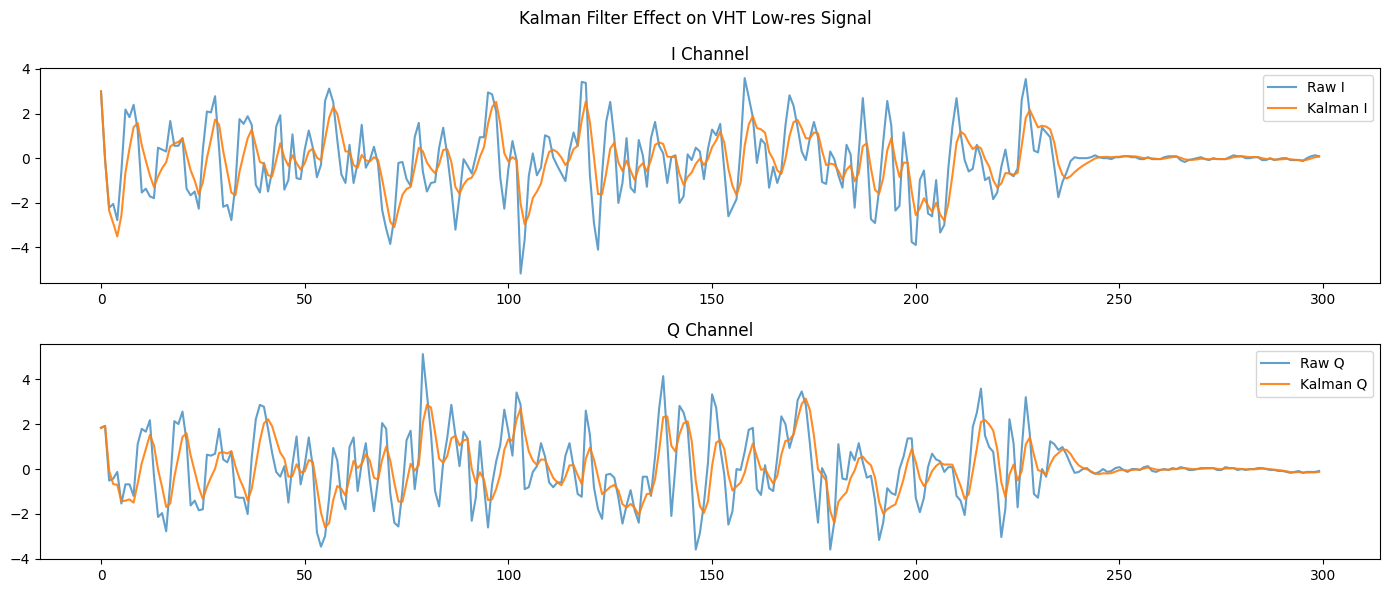

In [37]:
def kalman_filter_signal(signal, process_noise=1e-4, measurement_noise=1e-2):
    """
    Apply Kalman filter to IQ signal to smooth and enhance it.
    
    State: [amplitude, velocity]
    Observation: raw amplitude
    
    signal: (2, 2000) tensor — I and Q channels
    returns: (2, 2000) enhanced tensor
    """
    signal_np = signal.numpy()  # (2, 2000)
    output    = np.zeros_like(signal_np)
    
    for ch in range(2):
        x   = signal_np[ch]  # (2000,)
        n   = len(x)
        
        # State transition matrix — constant velocity model
        F = np.array([[1, 1],
                      [0, 1]])
        # Observation matrix — we only observe position
        H = np.array([[1, 0]])
        # Process noise covariance
        Q = process_noise * np.eye(2)
        # Measurement noise covariance
        R = np.array([[measurement_noise]])
        
        # Initialize state and covariance
        state = np.array([x[0], 0.0])
        P     = np.eye(2)
        
        filtered = np.zeros(n)
        
        for t in range(n):
            # Predict
            state = F @ state
            P     = F @ P @ F.T + Q
            
            # Update
            z   = np.array([x[t]])
            y   = z - H @ state
            S   = H @ P @ H.T + R
            K   = P @ H.T @ np.linalg.inv(S)
            state = state + K @ y
            P   = (np.eye(2) - K @ H) @ P
            
            filtered[t] = state[0]
        
        output[ch] = filtered
    
    return torch.tensor(output, dtype=signal.dtype)

# Test on one sample
idx     = (prot_train == 2).nonzero()[0].item()  # VHT sample
raw     = low_train[idx]
filtered = kalman_filter_signal(raw)

print(f"Raw signal stats:      mean={raw.mean():.4f}, std={raw.std():.4f}")
print(f"Filtered signal stats: mean={filtered.mean():.4f}, std={filtered.std():.4f}")

# Quick visual check
fig, axes = plt.subplots(2, 1, figsize=(14, 6))
fig.suptitle('Kalman Filter Effect on VHT Low-res Signal')

axes[0].plot(raw[0, :300].numpy(), label='Raw I', alpha=0.7)
axes[0].plot(filtered[0, :300].numpy(), label='Kalman I', alpha=0.9)
axes[0].legend()
axes[0].set_title('I Channel')

axes[1].plot(raw[1, :300].numpy(), label='Raw Q', alpha=0.7)
axes[1].plot(filtered[1, :300].numpy(), label='Kalman Q', alpha=0.9)
axes[1].legend()
axes[1].set_title('Q Channel')

plt.tight_layout()
plt.savefig('/workspace/kalman_preview.png', dpi=150, bbox_inches='tight')
plt.show()

PyWavelets version: 1.8.0
Raw signal stats:      mean=0.0016, std=0.7072
Wavelet signal stats:  mean=0.0016, std=0.6552


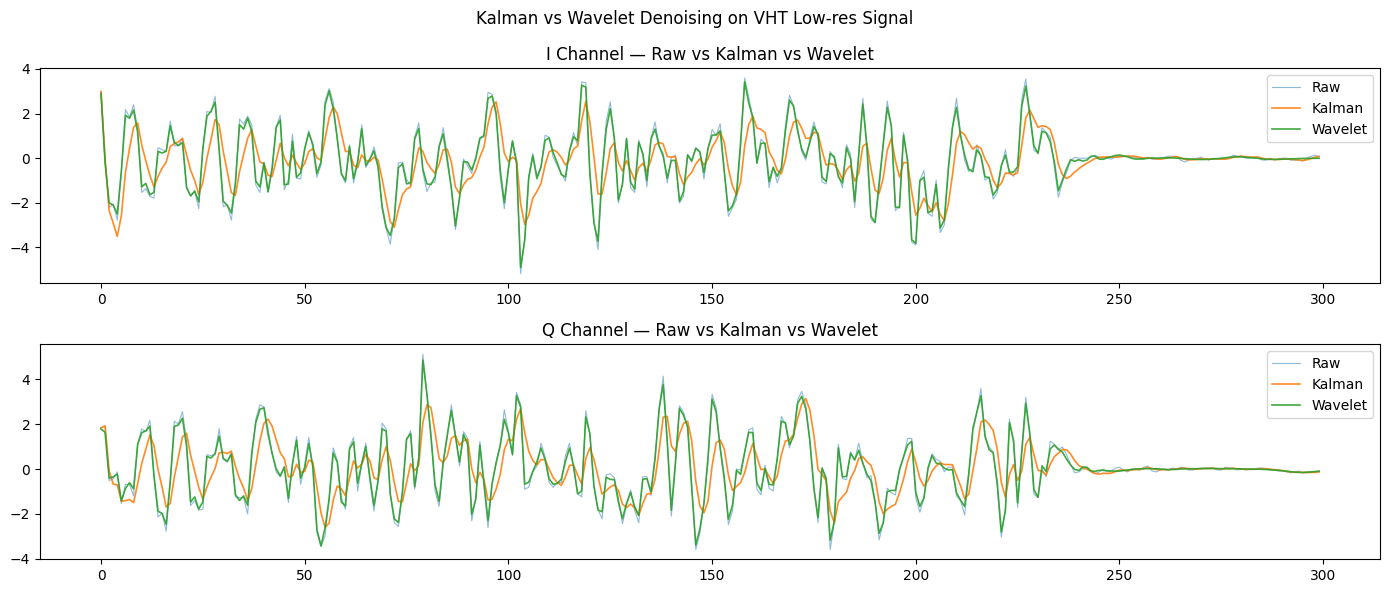

Saved!


In [38]:
import pywt

def wavelet_denoise(signal, wavelet='db4', level=3, threshold_mode='soft'):
    """
    Wavelet denoising on IQ signal.
    Decomposes signal into frequency sub-bands,
    thresholds small coefficients (noise), reconstructs.
    
    signal: (2, 2000) tensor
    returns: (2, 2000) denoised tensor
    """
    signal_np = signal.numpy()
    output    = np.zeros_like(signal_np)
    
    for ch in range(2):
        x = signal_np[ch]
        
        # Decompose
        coeffs = pywt.wavedec(x, wavelet, level=level)
        
        # Estimate noise from finest scale
        sigma = np.median(np.abs(coeffs[-1])) / 0.6745
        
        # Universal threshold
        threshold = sigma * np.sqrt(2 * np.log(len(x)))
        
        # Threshold all detail coefficients (keep approximation)
        coeffs_thresh = [coeffs[0]]  # keep approximation
        for c in coeffs[1:]:
            coeffs_thresh.append(pywt.threshold(c, threshold, mode=threshold_mode))
        
        # Reconstruct
        output[ch] = pywt.waverec(coeffs_thresh, wavelet)[:len(x)]
    
    return torch.tensor(output, dtype=signal.dtype)

# Test — check if pywt is installed
try:
    import pywt
    print(f"PyWavelets version: {pywt.__version__}")
except ImportError:
    print("Installing PyWavelets...")
    os.system("pip install PyWavelets --break-system-packages -q")
    import pywt
    print(f"PyWavelets version: {pywt.__version__}")

# Test on same VHT sample
denoised = wavelet_denoise(raw)

print(f"Raw signal stats:      mean={raw.mean():.4f}, std={raw.std():.4f}")
print(f"Wavelet signal stats:  mean={denoised.mean():.4f}, std={denoised.std():.4f}")

# Compare all three
fig, axes = plt.subplots(2, 1, figsize=(14, 6))
fig.suptitle('Kalman vs Wavelet Denoising on VHT Low-res Signal')

axes[0].plot(raw[0, :300].numpy(),      label='Raw',     alpha=0.5, linewidth=0.8)
axes[0].plot(filtered[0, :300].numpy(), label='Kalman',  alpha=0.9, linewidth=1.2)
axes[0].plot(denoised[0, :300].numpy(), label='Wavelet', alpha=0.9, linewidth=1.2)
axes[0].legend()
axes[0].set_title('I Channel — Raw vs Kalman vs Wavelet')

axes[1].plot(raw[1, :300].numpy(),      label='Raw',     alpha=0.5, linewidth=0.8)
axes[1].plot(filtered[1, :300].numpy(), label='Kalman',  alpha=0.9, linewidth=1.2)
axes[1].plot(denoised[1, :300].numpy(), label='Wavelet', alpha=0.9, linewidth=1.2)
axes[1].legend()
axes[1].set_title('Q Channel — Raw vs Kalman vs Wavelet')

plt.tight_layout()
plt.savefig('/workspace/kalman_vs_wavelet.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [40]:
# Wavelet preprocessing dataset
class WaveletDataset(torch.utils.data.Dataset):
    def __init__(self, data, augment=False):
        self.high, self.low, self.prot, self.lsig, self.htsig, self.has_htsig = data
        self.augment = augment

    def __len__(self):
        return len(self.prot)

    def __getitem__(self, idx):
        high = self.high[idx].clone()
        low  = self.low[idx].clone()

        if self.augment:
            theta = torch.empty(1).uniform_(0, 2 * 3.14159265).item()
            cos_t = torch.cos(torch.tensor(theta))
            sin_t = torch.sin(torch.tensor(theta))
            for iq in (high, low):
                real  = iq[0].clone()
                iq[0] = real * cos_t - iq[1] * sin_t
                iq[1] = real * sin_t + iq[1] * cos_t

        # Apply wavelet denoising to low-res signal
        low = wavelet_denoise(low)

        return high, low, self.prot[idx], self.lsig[idx], self.htsig[idx], self.has_htsig[idx]

print("Testing wavelet dataset speed...")
wav_ds = WaveletDataset(train_data, augment=True)
t0 = time.time()
for i in range(100):
    _ = wav_ds[i]
print(f"100 samples: {time.time()-t0:.2f}s → {(time.time()-t0)/100*1000:.1f}ms per sample")
print("Ready to train")

Testing wavelet dataset speed...
100 samples: 0.02s → 0.2ms per sample
Ready to train


In [42]:
class WiFiModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = IQEncoder()
        self.decoder = WiFiDecoder()

    def forward(self, x):
        emb = self.encoder(x)
        prot_l, lsig_l, htsig_l = self.decoder(emb)
        return prot_l, lsig_l, htsig_l, emb, emb, emb

In [46]:
import os, gc, time, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

gc.collect()
torch.cuda.empty_cache()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True

NUM_PROT = 4
LSIG_LEN = 24
HTSIG_LEN = 48

# Load data if not already loaded
if "train_data" not in globals():
    train_data = torch.load("/workspace/data/train.pt")
if "test_data" not in globals():
    test_data = torch.load("/workspace/data/test.pt")

class WaveletDataset(Dataset):
    def __init__(self, data, augment=False):
        self.high, self.low, self.prot, self.lsig, self.htsig, self.has_htsig = data
        self.augment = augment

    def __len__(self):
        return len(self.prot)

    def __getitem__(self, idx):
        high = self.high[idx].clone()
        low = self.low[idx].clone()

        if self.augment:
            theta = torch.empty(1).uniform_(0, 2 * np.pi).item()
            c = torch.cos(torch.tensor(theta))
            s = torch.sin(torch.tensor(theta))

            for iq in (high, low):
                real = iq[0].clone()
                imag = iq[1].clone()
                iq[0] = real * c - imag * s
                iq[1] = real * s + imag * c

        return high, low, self.prot[idx], self.lsig[idx], self.htsig[idx], self.has_htsig[idx]

class IQEncoder(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv1d(2, 64, kernel_size=9, padding=4),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=7, padding=3),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.MaxPool1d(2),

            nn.Conv1d(128, 256, kernel_size=5, padding=2),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.MaxPool1d(2),

            nn.Conv1d(256, embed_dim, kernel_size=3, padding=1),
            nn.BatchNorm1d(embed_dim),
            nn.GELU(),
        )

        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=8,
            dim_feedforward=1024,
            dropout=0.1,
            batch_first=True,
            norm_first=True,
        )

        self.transformer = nn.TransformerEncoder(
            enc_layer,
            num_layers=2,
            enable_nested_tensor=False,
        )

        self.pool = nn.AdaptiveAvgPool1d(1)

    def forward(self, x):
        # x: (B, 2, 2000)
        z = self.cnn(x)              # (B, 512, T)
        tokens = z.transpose(1, 2)   # (B, T, 512)
        tokens = self.transformer(tokens)
        z = tokens.transpose(1, 2)   # (B, 512, T)
        emb = self.pool(z).squeeze(-1)
        return emb

class WiFiDecoder(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()

        self.prot_head = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(256, NUM_PROT),
        )

        self.lsig_head = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(256, LSIG_LEN),
        )

        self.htsig_head = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(256, HTSIG_LEN),
        )

    def forward(self, emb):
        return self.prot_head(emb), self.lsig_head(emb), self.htsig_head(emb)

class WiFiModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = IQEncoder()
        self.decoder = WiFiDecoder()

    def forward(self, x):
        emb = self.encoder(x)
        prot_l, lsig_l, htsig_l = self.decoder(emb)
        return prot_l, lsig_l, htsig_l, emb, None, None

def task_loss_balanced(prot_l, lsig_l, htsig_l, prot_gt, lsig_gt, htsig_gt, has_htsig):
    w = torch.tensor([0.5, 1.5, 8.0, 8.0], device=prot_l.device, dtype=prot_l.dtype)

    loss = F.cross_entropy(prot_l, prot_gt, weight=w)
    loss += F.binary_cross_entropy_with_logits(lsig_l.float(), lsig_gt.float())

    mask = has_htsig.bool()
    if mask.any():
        loss += F.binary_cross_entropy_with_logits(
            htsig_l[mask].float(),
            htsig_gt[mask].float()
        )

    return loss

def bit_acc(logits, targets):
    return ((logits.sigmoid() > 0.5).float() == targets).float().mean().item()

def prot_acc(logits, targets):
    return (logits.argmax(1) == targets).float().mean().item()

def get_scheduler_with_warmup(optimizer, warmup_epochs, total_epochs):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
        return 0.5 * (1 + np.cos(progress * np.pi))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    tot_loss = tot_prot = tot_lsig = 0.0

    for high_iq, low_iq, prot, lsig, htsig, has_htsig in loader:
        iq = low_iq.to(DEVICE, non_blocking=True)
        prot = prot.to(DEVICE, non_blocking=True).long()
        lsig = lsig.to(DEVICE, non_blocking=True).float()
        htsig = htsig.to(DEVICE, non_blocking=True).float()
        has_htsig = has_htsig.to(DEVICE, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda")):
            prot_l, lsig_l, htsig_l, _, _, _ = model(iq)
            loss = task_loss_balanced(prot_l, lsig_l, htsig_l, prot, lsig, htsig, has_htsig)

        tot_loss += loss.item()
        tot_prot += prot_acc(prot_l, prot)
        tot_lsig += bit_acc(lsig_l, lsig)

    n = len(loader)
    return tot_loss / n, tot_prot / n, tot_lsig / n

WAV_EPOCHS = 40
WAV_LR = 3e-4
WARMUP_EPOCHS = 3
ACCUM_STEPS = 2
BATCH_SIZE = 256

wav_train_ds = WaveletDataset(train_data, augment=True)
wav_test_ds = WaveletDataset(test_data, augment=False)

wav_loader = DataLoader(
    wav_train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)

wav_test_loader = DataLoader(
    wav_test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

wav_model = WiFiModel().to(DEVICE)
w_opt = torch.optim.AdamW(wav_model.parameters(), lr=WAV_LR, weight_decay=1e-4)
w_sched = get_scheduler_with_warmup(w_opt, WARMUP_EPOCHS, WAV_EPOCHS)
w_scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE.type == "cuda"))
best_w_prot = 0.0

total_params = sum(p.numel() for p in wav_model.parameters())
print(f"Device: {DEVICE}")
print(f"Parameters: {total_params:,}")
print(f"\n{'Ep':>3} {'tr_loss':>8} {'tr_prot':>8} {'tr_lsig':>8} {'va_prot':>8} {'va_lsig':>8} {'lr':>8} {'time':>6}")
print("-" * 70)

for epoch in range(1, WAV_EPOCHS + 1):
    wav_model.train()
    t0 = time.time()
    tot_loss = tot_prot = tot_lsig = 0.0
    w_opt.zero_grad(set_to_none=True)

    for i, (high_iq, low_iq, prot, lsig, htsig, has_htsig) in enumerate(wav_loader):
        low_iq = low_iq.to(DEVICE, non_blocking=True)
        prot = prot.to(DEVICE, non_blocking=True).long()
        lsig = lsig.to(DEVICE, non_blocking=True).float()
        htsig = htsig.to(DEVICE, non_blocking=True).float()
        has_htsig = has_htsig.to(DEVICE, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda")):
            prot_l, lsig_l, htsig_l, _, _, _ = wav_model(low_iq)
            loss = task_loss_balanced(
                prot_l, lsig_l, htsig_l,
                prot, lsig, htsig, has_htsig
            ) / ACCUM_STEPS

        w_scaler.scale(loss).backward()

        if (i + 1) % ACCUM_STEPS == 0 or (i + 1) == len(wav_loader):
            w_scaler.unscale_(w_opt)
            torch.nn.utils.clip_grad_norm_(wav_model.parameters(), 1.0)
            w_scaler.step(w_opt)
            w_scaler.update()
            w_opt.zero_grad(set_to_none=True)

        tot_loss += loss.item() * ACCUM_STEPS
        tot_prot += prot_acc(prot_l.detach(), prot)
        tot_lsig += bit_acc(lsig_l.detach(), lsig)

    w_sched.step()

    n = len(wav_loader)
    tr = (tot_loss / n, tot_prot / n, tot_lsig / n)
    va = evaluate(wav_model, wav_test_loader)
    lr = w_opt.param_groups[0]["lr"]

    if va[1] > best_w_prot:
        best_w_prot = va[1]
        torch.save(wav_model.state_dict(), "/workspace/wavelet_best.pt")
        marker = " <- best"
    else:
        marker = ""

    print(
        f"{epoch:3d} {tr[0]:8.4f} {tr[1]:8.3f} {tr[2]:8.3f} "
        f"{va[1]:8.3f} {va[2]:8.3f} {lr:8.2e} {time.time()-t0:5.0f}s{marker}",
        flush=True
    )

print(f"\nBest Wavelet va_prot: {best_w_prot:.4f}")

Device: cuda
Parameters: 5,237,516

 Ep  tr_loss  tr_prot  tr_lsig  va_prot  va_lsig       lr   time
----------------------------------------------------------------------
  1   1.3967    0.727    0.875    0.866    0.897 2.00e-04    18s <- best
  2   0.8837    0.914    0.897    0.908    0.909 3.00e-04    18s <- best
  3   0.7137    0.950    0.912    0.922    0.922 3.00e-04    18s <- best
  4   0.5971    0.962    0.929    0.922    0.930 2.99e-04    17s
  5   0.5401    0.967    0.938    0.943    0.928 2.98e-04    18s <- best
  6   0.5037    0.970    0.944    0.924    0.935 2.95e-04    17s
  7   0.4702    0.972    0.949    0.940    0.941 2.91e-04    18s
  8   0.4460    0.975    0.953    0.932    0.944 2.87e-04    18s
  9   0.4147    0.974    0.959    0.942    0.950 2.81e-04    18s
 10   0.3883    0.976    0.965    0.936    0.954 2.74e-04    18s
 11   0.3695    0.978    0.967    0.943    0.953 2.67e-04    18s <- best
 12   0.3584    0.977    0.969    0.938    0.956 2.58e-04    17s
 13   0.

In [47]:
wav_model.load_state_dict(torch.load("/workspace/wavelet_best.pt", map_location=DEVICE))
wav_model.eval()

correct = torch.zeros(4)
total = torch.zeros(4)

with torch.no_grad():
    for high_iq, low_iq, prot, *_ in wav_test_loader:
        iq = low_iq.to(DEVICE)
        prot_g = prot.to(DEVICE)

        with torch.amp.autocast("cuda"):
            prot_l, _, _, _, _, _ = wav_model(iq)

        preds = prot_l.argmax(1)

        for c in range(4):
            mask = prot_g == c
            correct[c] += (preds[mask] == prot_g[mask]).sum().cpu()
            total[c] += mask.sum().cpu()

print("\nPer-class accuracy (Wavelet):")
for c in range(4):
    acc = correct[c] / (total[c] + 1e-8) * 100
    print(f"{PROT_NAMES[c]:>8}: {acc.item():.1f}%")


Per-class accuracy (Wavelet):
  Non-HT: 96.5%
      HT: 91.0%
     VHT: 59.0%
    HTGF: 0.0%


```

Device: cuda
Parameters: 5,237,516

 Ep  tr_loss  tr_prot  tr_lsig  va_prot  va_lsig       lr   time
----------------------------------------------------------------------
  1   1.3967    0.727    0.875    0.866    0.897 2.00e-04    18s <- best
  2   0.8837    0.914    0.897    0.908    0.909 3.00e-04    18s <- best
  3   0.7137    0.950    0.912    0.922    0.922 3.00e-04    18s <- best
  4   0.5971    0.962    0.929    0.922    0.930 2.99e-04    17s
  5   0.5401    0.967    0.938    0.943    0.928 2.98e-04    18s <- best
  6   0.5037    0.970    0.944    0.924    0.935 2.95e-04    17s
  7   0.4702    0.972    0.949    0.940    0.941 2.91e-04    18s
  8   0.4460    0.975    0.953    0.932    0.944 2.87e-04    18s
  9   0.4147    0.974    0.959    0.942    0.950 2.81e-04    18s
 10   0.3883    0.976    0.965    0.936    0.954 2.74e-04    18s
 11   0.3695    0.978    0.967    0.943    0.953 2.67e-04    18s <- best
 12   0.3584    0.977    0.969    0.938    0.956 2.58e-04    17s
 13   0.3428    0.978    0.971    0.940    0.959 2.49e-04    18s
 14   0.3251    0.979    0.973    0.938    0.958 2.39e-04    18s
 15   0.3200    0.978    0.973    0.929    0.958 2.29e-04    17s
 16   0.3078    0.979    0.974    0.941    0.961 2.18e-04    17s
 17   0.2949    0.979    0.975    0.940    0.961 2.06e-04    18s
 18   0.2878    0.980    0.976    0.937    0.962 1.94e-04    17s
 19   0.2755    0.980    0.977    0.935    0.962 1.82e-04    18s
 20   0.2725    0.980    0.977    0.944    0.961 1.69e-04    17s <- best
 21   0.2638    0.981    0.978    0.940    0.963 1.56e-04    17s
 22   0.2494    0.982    0.978    0.943    0.963 1.44e-04    17s
 23   0.2440    0.983    0.979    0.936    0.964 1.31e-04    17s
 24   0.2349    0.983    0.979    0.939    0.964 1.18e-04    18s
 25   0.2293    0.983    0.980    0.940    0.964 1.06e-04    17s
 26   0.2194    0.984    0.980    0.936    0.964 9.41e-05    17s
 27   0.2130    0.985    0.980    0.934    0.964 8.25e-05    17s
 28   0.2030    0.985    0.981    0.938    0.965 7.14e-05    17s
 29   0.2013    0.986    0.981    0.934    0.964 6.08e-05    17s
 30   0.1973    0.986    0.981    0.943    0.965 5.09e-05    17s
 31   0.1912    0.987    0.981    0.942    0.965 4.17e-05    17s
 32   0.1865    0.988    0.981    0.939    0.965 3.33e-05    17s
 33   0.1842    0.989    0.982    0.938    0.965 2.57e-05    17s
 34   0.1795    0.989    0.982    0.943    0.965 1.90e-05    18s
 35   0.1756    0.990    0.982    0.944    0.965 1.33e-05    18s
 36   0.1742    0.990    0.982    0.944    0.965 8.57e-06    18s
 37   0.1720    0.990    0.982    0.943    0.965 4.84e-06    17s
 38   0.1731    0.990    0.982    0.943    0.965 2.16e-06    17s
 39   0.1714    0.990    0.982    0.943    0.965 5.40e-07    17s
 40   0.1702    0.990    0.982    0.943    0.965 0.00e+00    17s

Best Wavelet va_prot: 0.9443
Per-class accuracy (Wavelet):
  Non-HT: 96.5%
      HT: 91.0%
     VHT: 59.0%
    HTGF: 0.0%
```